In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dask.dataframe as dd
import pickle
import os

In [2]:
# data_dir = "sameBlock"
# data_dir = "sameSuperblock"
data_dir = "sameBlockWithHigherOrderStats"

In [3]:
# —Later— to load:
if data_dir != "sameBlockWithHigherOrderStats":
    with open(f'./{data_dir}/estimators.pkl', 'rb') as f:
        estimators = pickle.load(f)
else:
    with open(f'./{data_dir}/standard_disjoint_estimators.pkl', 'rb') as f:
        standard_disjoint_estimators = pickle.load(f)
    with open(f'./{data_dir}/standard_overlapping_estimators.pkl', 'rb') as f:
        standard_overlapping_estimators = pickle.load(f)
    with open(f'./{data_dir}/standard_sampled_estimators.pkl', 'rb') as f:
        standard_sampled_estimators = pickle.load(f)
    with open(f'./{data_dir}/bs_disjoint_estimators.pkl', 'rb') as f:
        bs_disjoint_estimators = pickle.load(f)
    with open(f'./{data_dir}/bs_overlapping_estimators.pkl', 'rb') as f:
        bs_overlapping_estimators = pickle.load(f)
    with open(f'./{data_dir}/bs_sampled_estimators.pkl', 'rb') as f:
        bs_sampled_estimators = pickle.load(f)

        # Bundle all dicts into one object
    estimators = {
        'means': {
            "standard_disjoint_estimator": standard_disjoint_estimators["standard_disjoint_estimator"],
            "bs_disjoint_estimator": bs_disjoint_estimators["bs_disjoint_estimator"],
            "standard_overlapping_estimator": standard_overlapping_estimators["standard_overlapping_estimator"],
            "bs_overlapping_estimator": bs_overlapping_estimators["bs_overlapping_estimator"],
            "standard_sampled_estimator": standard_sampled_estimators["standard_sampled_estimator"],
            "bs_sampled_estimator": bs_sampled_estimators["bs_sampled_estimator"],
        },
        'stds': {
            "standard_disjoint_std_estimator": standard_disjoint_estimators["standard_disjoint_std_estimator"],
            "bs_disjoint_std_estimator": bs_disjoint_estimators["bs_disjoint_std_estimator"],
            "standard_overlapping_std_estimator": standard_overlapping_estimators["standard_overlapping_std_estimator"],
            "bs_overlapping_std_estimator": bs_overlapping_estimators["bs_overlapping_std_estimator"],
            "standard_sampled_std_estimator": standard_sampled_estimators["standard_sampled_std_estimator"],
            "bs_sampled_std_estimator": bs_sampled_estimators["bs_sampled_std_estimator"]
        },
        'skews': {
            "standard_disjoint_skew_estimator": standard_disjoint_estimators["standard_disjoint_skew_estimator"],
            "bs_disjoint_skew_estimator": bs_disjoint_estimators["bs_disjoint_skew_estimator"],
            "standard_overlapping_skew_estimator": standard_overlapping_estimators["standard_overlapping_skew_estimator"],
            "bs_overlapping_skew_estimator": bs_overlapping_estimators["bs_overlapping_skew_estimator"],
            "standard_sampled_skew_estimator": standard_sampled_estimators["standard_sampled_skew_estimator"],
            "bs_sampled_skew_estimator": bs_sampled_estimators["bs_sampled_skew_estimator"]
        },
        'kurts': {
            "standard_disjoint_kurt_estimator": standard_disjoint_estimators["standard_disjoint_kurt_estimator"],
            "bs_disjoint_kurt_estimator": bs_disjoint_estimators["bs_disjoint_kurt_estimator"],
            "standard_overlapping_kurt_estimator": standard_overlapping_estimators["standard_overlapping_kurt_estimator"],
            "bs_overlapping_kurt_estimator": bs_overlapping_estimators["bs_overlapping_kurt_estimator"],
            "standard_sampled_kurt_estimator": standard_sampled_estimators["standard_sampled_kurt_estimator"],
            "bs_sampled_kurt_estimator": bs_sampled_estimators["bs_sampled_kurt_estimator"]
        }
    }

In [4]:

# —Later— to reload:
with open(f'./{data_dir}/all_maximas_summary.pkl', 'rb') as f:
    summary_stats = pickle.load(f)


In [5]:
summary_stats

{'disjoint': {'series1': {'describe':                  SBM
   count  995500.000000
   mean        3.642272
   std         0.367811
   min         2.544763
   25%         3.441562
   50%         3.665463
   75%         3.940239
   max         6.346192,
   'skewness': SBM    0.722112
   dtype: float64,
   'kurtosis': SBM    0.890379
   dtype: float64},
  'series0': {'describe':                  SBM
   count  998000.000000
   mean        3.992134
   std         0.309995
   min         3.129973
   25%         3.821748
   50%         4.006383
   75%         4.240380
   max         6.630596,
   'skewness': SBM    0.845904
   dtype: float64,
   'kurtosis': SBM    1.27599
   dtype: float64},
  'series3': {'describe':                  SBM
   count  632500.000000
   mean        3.454370
   std         0.443069
   min         1.948546
   25%         3.203615
   50%         3.473898
   75%         3.831256
   max         6.535407,
   'skewness': SBM    0.511464
   dtype: float64,
   'kurtosis': SB

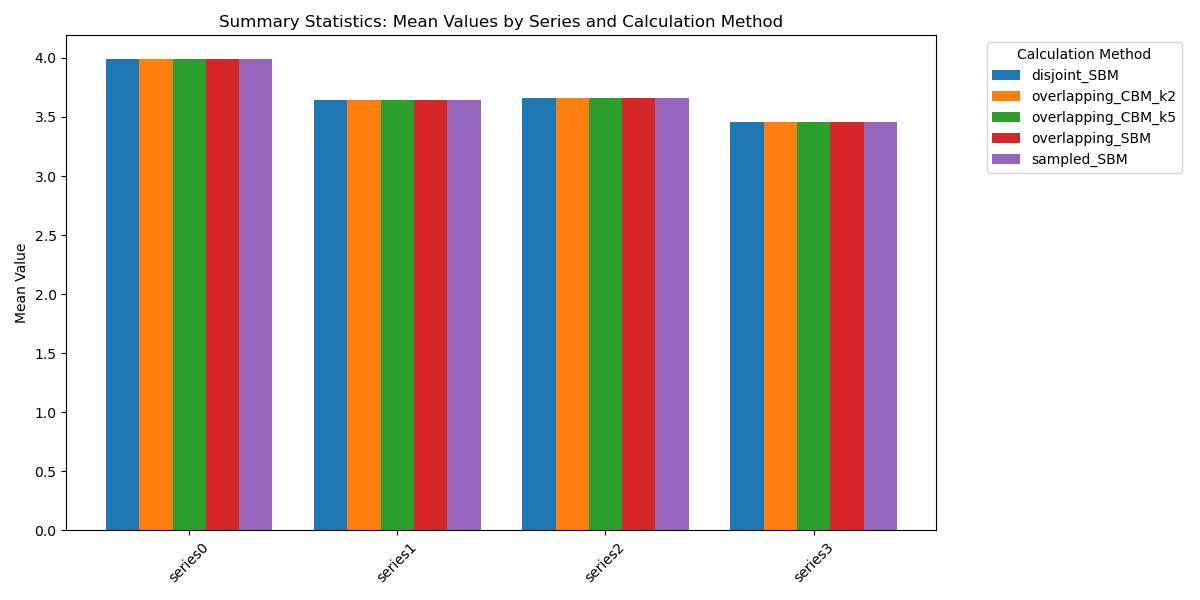

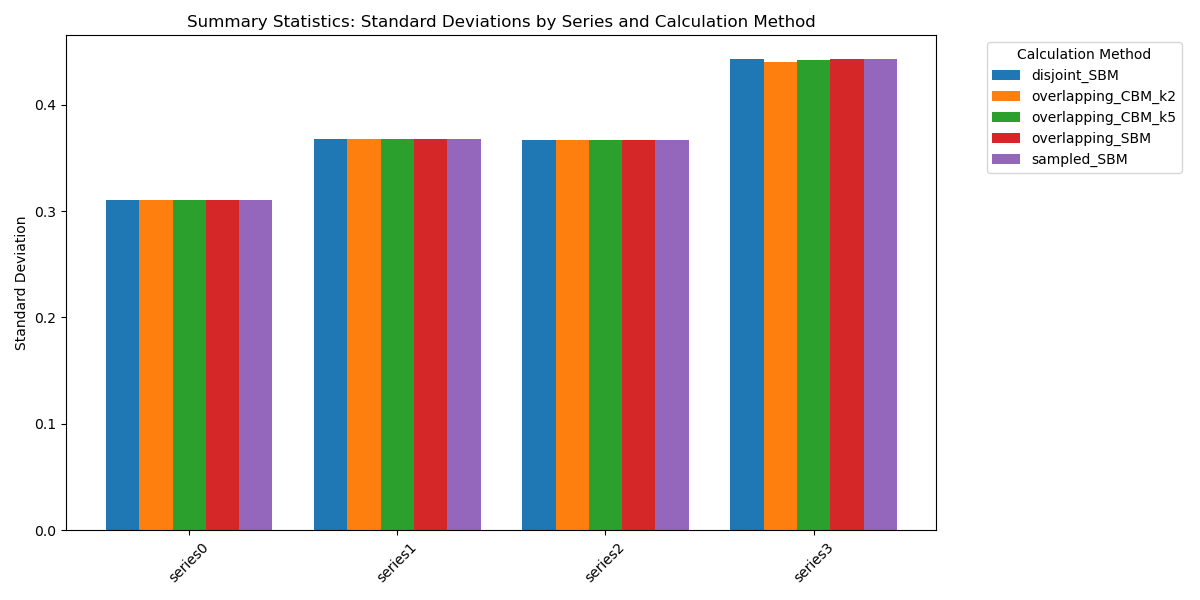

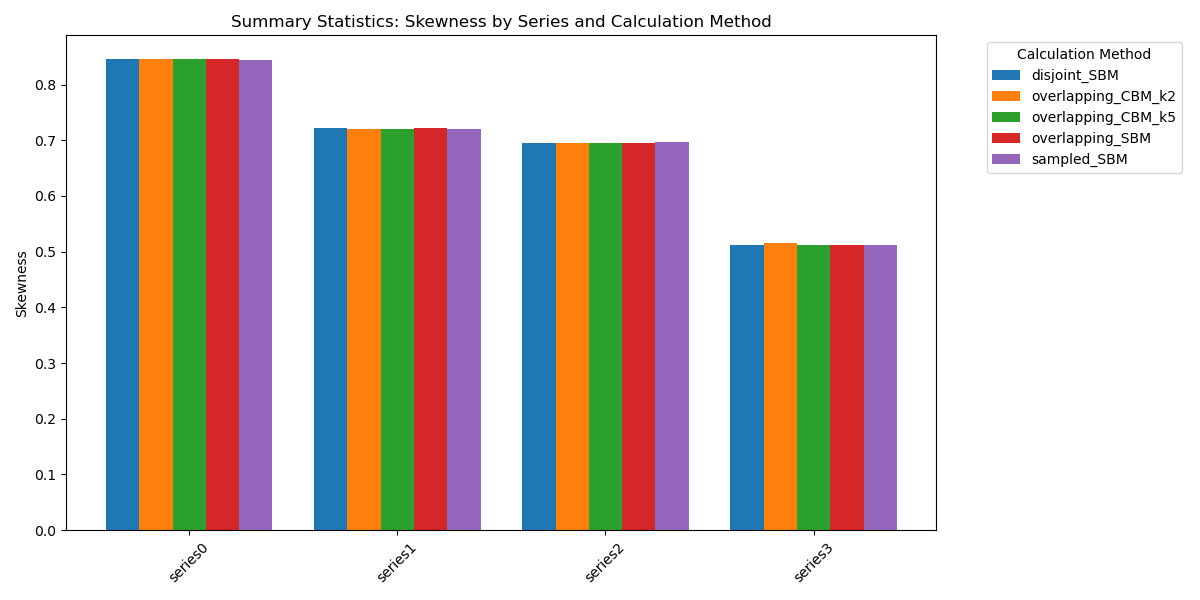

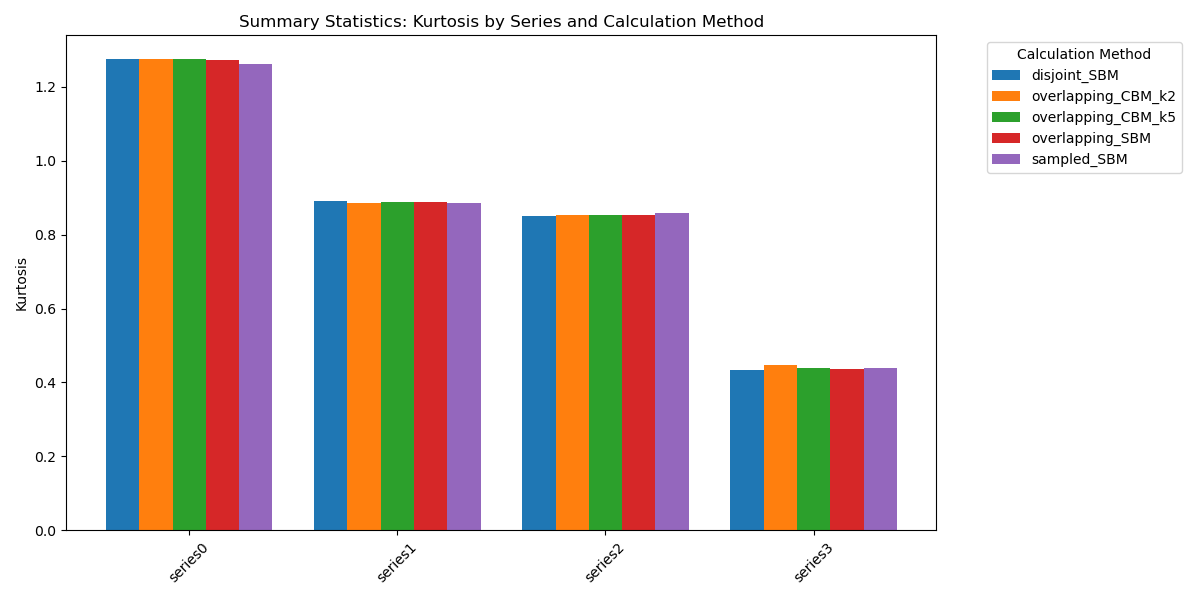

In [7]:
# Helpers for reading true summary statistics across supported formats.
def get_available_columns(stats_entry):
    if isinstance(stats_entry, dict):
        describe_df = stats_entry.get('describe')
        if isinstance(describe_df, pd.DataFrame):
            return list(describe_df.columns)

        for key in ['skewness', 'kurtosis']:
            stat_obj = stats_entry.get(key)
            if isinstance(stat_obj, pd.Series):
                return list(stat_obj.index)
            if isinstance(stat_obj, pd.DataFrame):
                return list(stat_obj.columns)
        return []

    if isinstance(stats_entry, pd.DataFrame):
        return list(stats_entry.columns)

    return []


def get_true_stat(stats_entry, col, stat_name):
    # New format: {'describe': DataFrame, 'skewness': Series, 'kurtosis': Series}
    if isinstance(stats_entry, dict):
        if stat_name in ['mean', 'std']:
            describe_df = stats_entry.get('describe')
            if isinstance(describe_df, pd.DataFrame):
                if stat_name in describe_df.index and col in describe_df.columns:
                    return describe_df.at[stat_name, col]
            return np.nan

        if stat_name == 'skewness':
            skew_obj = stats_entry.get('skewness')
            if isinstance(skew_obj, pd.Series):
                return skew_obj.get(col, np.nan)
            if isinstance(skew_obj, pd.DataFrame):
                if col in skew_obj.columns:
                    if 'skewness' in skew_obj.index:
                        return skew_obj.at['skewness', col]
                    return skew_obj[col].iloc[0]
            return np.nan

        if stat_name == 'kurtosis':
            kurt_obj = stats_entry.get('kurtosis')
            if isinstance(kurt_obj, pd.Series):
                return kurt_obj.get(col, np.nan)
            if isinstance(kurt_obj, pd.DataFrame):
                if col in kurt_obj.columns:
                    if 'kurtosis' in kurt_obj.index:
                        return kurt_obj.at['kurtosis', col]
                    return kurt_obj[col].iloc[0]
            return np.nan

    # Legacy format: DataFrame where stats are index values (mean, std, ...).
    if isinstance(stats_entry, pd.DataFrame):
        if stat_name in stats_entry.index and col in stats_entry.columns:
            return stats_entry.at[stat_name, col]

    return np.nan


def build_stat_dataframe(stat_name, value_label):
    stat_data = []

    for calc_method, series_dict in summary_stats.items():
        for series_name, stats_entry in series_dict.items():
            cols = get_available_columns(stats_entry)

            for col in cols:
                stat_value = get_true_stat(stats_entry, col, stat_name)
                if pd.isna(stat_value):
                    continue

                stat_data.append({
                    'Series': series_name,
                    'Calculation Method': f"{calc_method}_{col}",
                    value_label: stat_value,
                })

    if len(stat_data) == 0:
        return None

    stat_df = pd.DataFrame(stat_data)
    return stat_df.pivot(index='Series', columns='Calculation Method', values=value_label)


plot_specs = [
    ('mean', 'Mean Value', 'Summary Statistics: Mean Values by Series and Calculation Method', 'Mean Value'),
    ('std', 'Standard Deviation', 'Summary Statistics: Standard Deviations by Series and Calculation Method', 'Standard Deviation'),
    ('skewness', 'Skewness', 'Summary Statistics: Skewness by Series and Calculation Method', 'Skewness'),
    ('kurtosis', 'Kurtosis', 'Summary Statistics: Kurtosis by Series and Calculation Method', 'Kurtosis'),
]

for stat_name, value_label, title, y_label in plot_specs:
    plot_df = build_stat_dataframe(stat_name, value_label)
    if plot_df is None:
        print(f"Skipping '{stat_name}' initial bar plot: not available in summary_stats.")
        continue

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(plot_df.index))
    width = 0.8 / len(plot_df.columns)

    for i, col in enumerate(plot_df.columns):
        offset = i * width - (len(plot_df.columns) - 1) * width / 2
        ax.bar(x + offset, plot_df[col], width, label=col)

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=45)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend(title='Calculation Method', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

In [ ]:
suffix_map = {
    'means': '_mean',
    'stds': '_std',
    'skews': '_skew',
    'kurts': '_kurt',
}

for metric, suffix in suffix_map.items():
    if metric not in estimators:
        continue

    for estimator_name, metric_series in estimators[metric].items():
        for series_name in metric_series.keys():
            estimators[metric][estimator_name][series_name] = metric_series[series_name].rename(
                lambda x, suffix=suffix: x.replace(suffix, ''), axis=1
            )

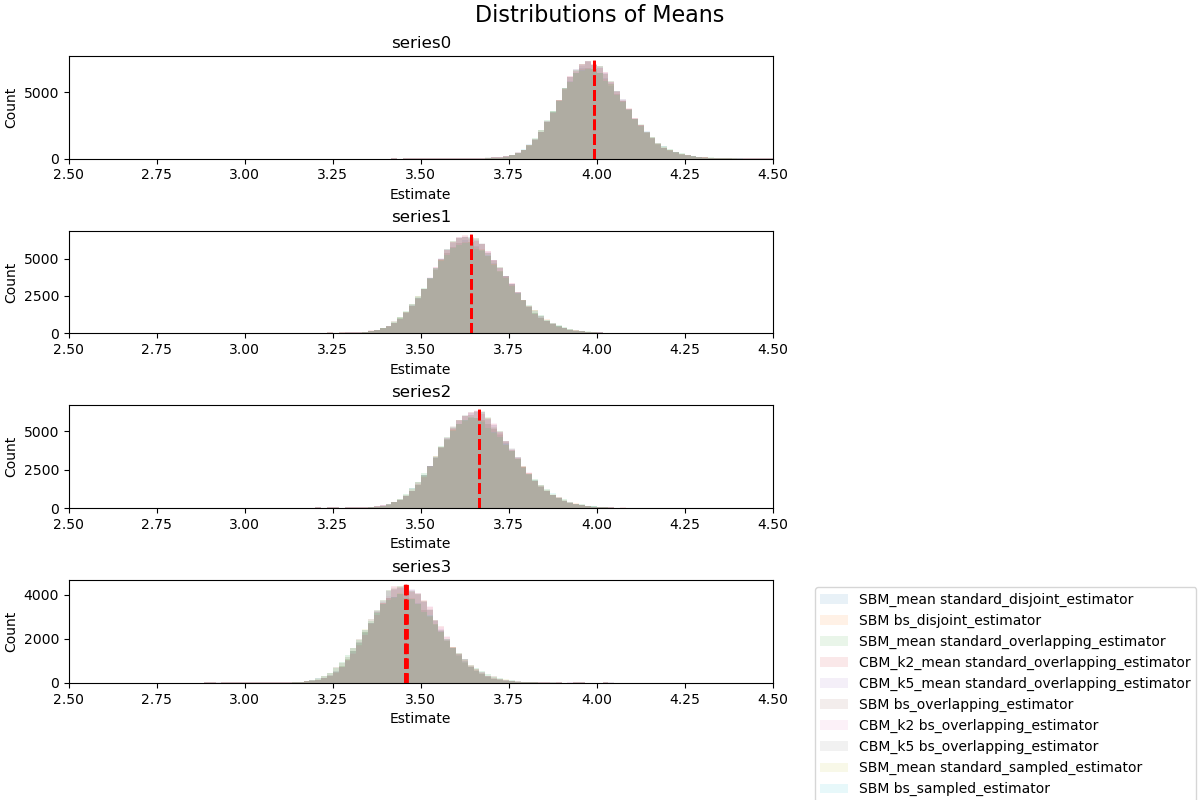

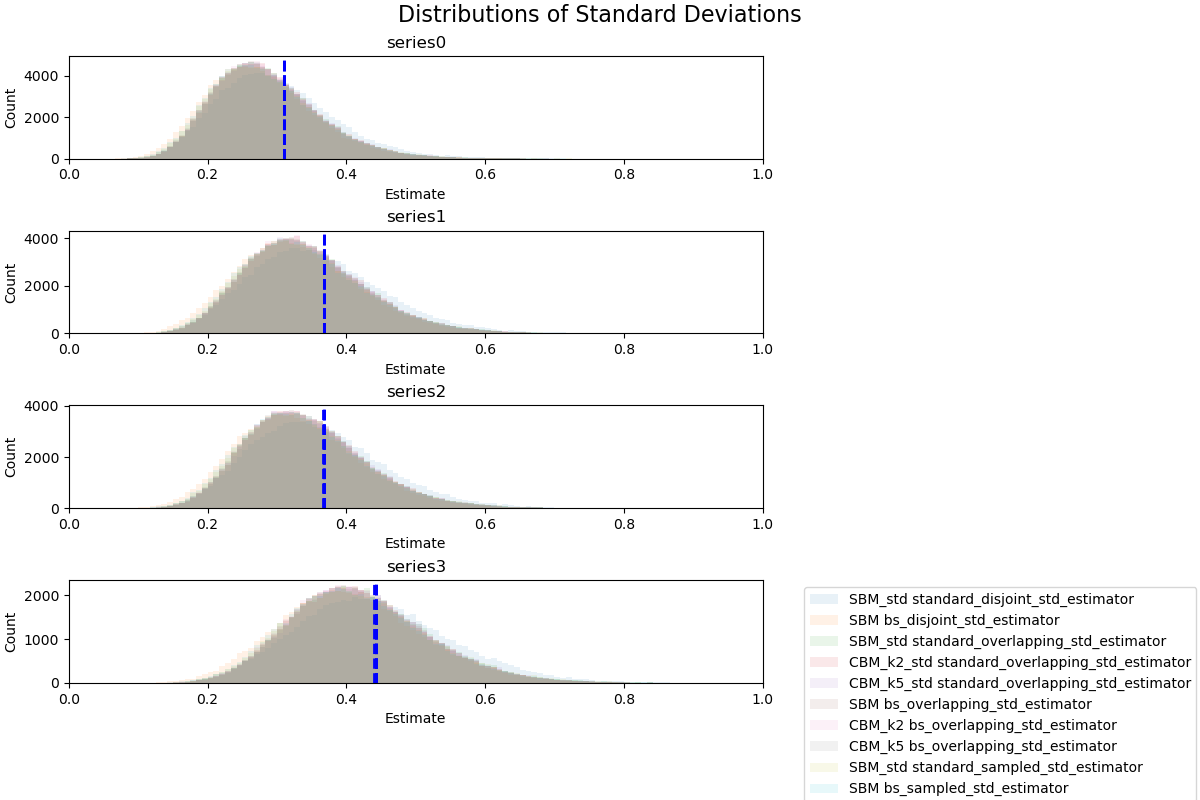

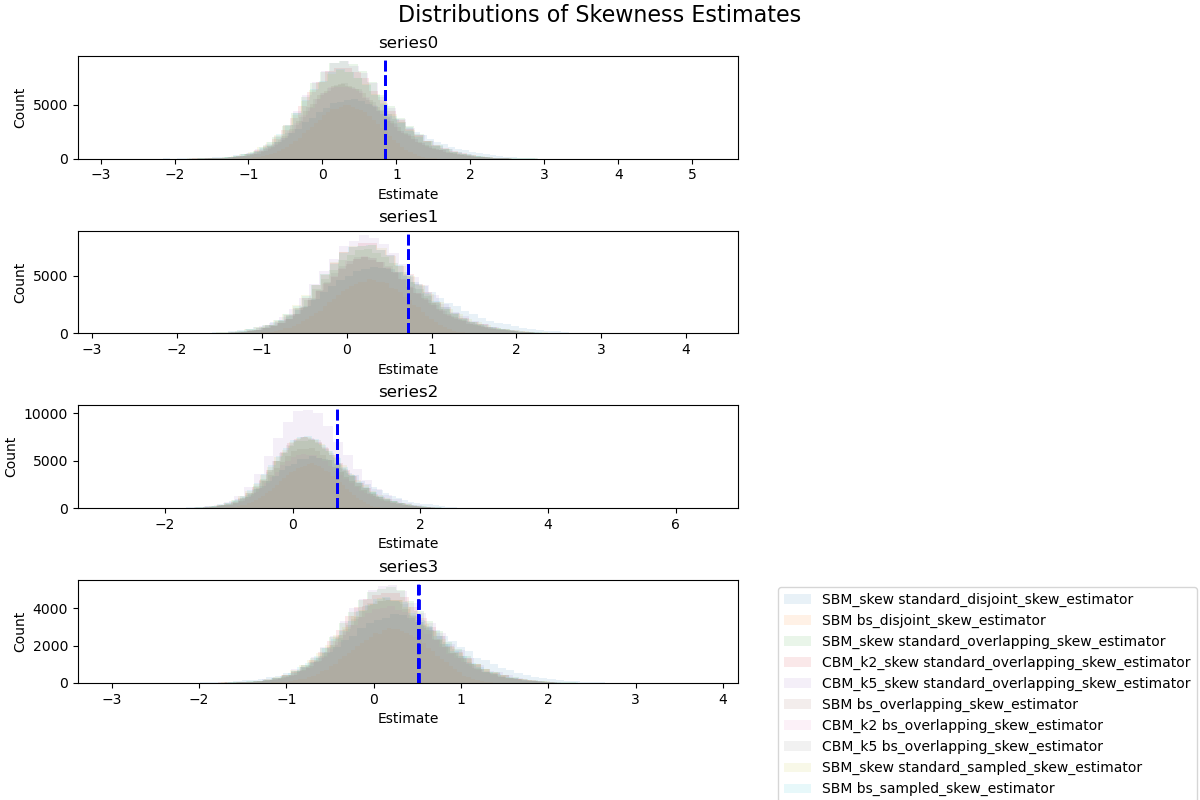

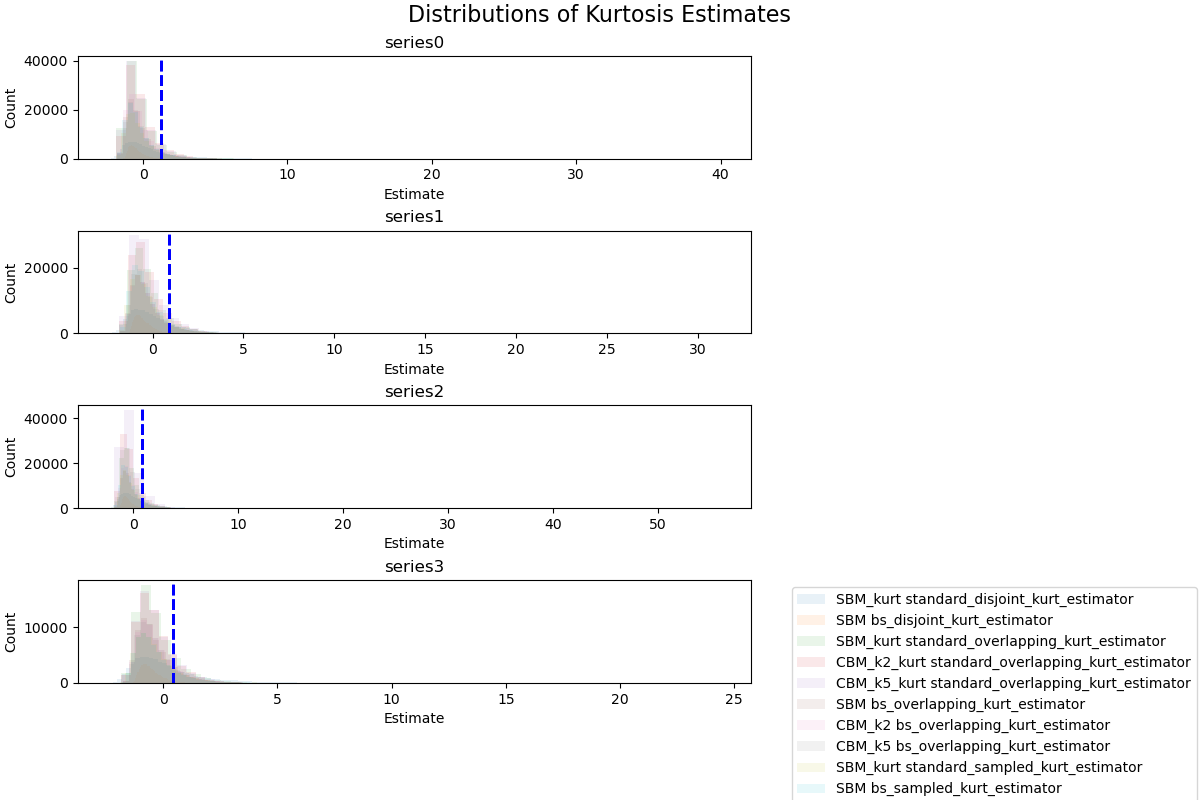

In [8]:
# Create figures for each metric family using true references when available in summary_stats.
figures = {}
axes = {}

plot_configs = [
    ('means', 'Distributions of Means', (2.5, 4.5), 'mean'),
    ('stds', 'Distributions of Standard Deviations', (0, 1), 'std'),
    ('skews', 'Distributions of Skewness Estimates', None, 'skewness'),
    ('kurts', 'Distributions of Kurtosis Estimates', None, 'kurtosis'),
]

for metric, title, x_limits, reference_stat in plot_configs:
    if metric not in estimators or len(estimators[metric]) == 0:
        continue

    combined_data = estimators[metric]
    series_names = sorted(combined_data[list(combined_data.keys())[0]].keys())

    fig, axs = plt.subplots(len(series_names), 1, figsize=(12, 8), constrained_layout=True)
    if len(series_names) == 1:
        axs = [axs]

    figures[metric] = fig
    axes[metric] = axs

    for estimator_name in combined_data.keys():
        data = combined_data[estimator_name]

        for col_idx, series_name in enumerate(series_names):
            ax = axs[col_idx]

            if x_limits is not None:
                ax.set_xlim(*x_limits)

            stat_group = estimator_name.split('_')[1]
            stats_entry = summary_stats.get(stat_group, {}).get(series_name, {})

            for col in data[series_name].columns:
                values = data[series_name][col].dropna().values

                if x_limits is not None:
                    bins = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 121)
                else:
                    bins = 60

                ax.hist(values, bins=bins, alpha=0.1, label=f'{col} {estimator_name}')

                true_value = get_true_stat(stats_entry, col, reference_stat)
                if pd.notna(true_value):
                    ax.axvline(
                        true_value,
                        color='r' if metric == 'means' else 'b',
                        linestyle='--',
                        linewidth=2,
                        label=None,
                    )

            ax.set_title(f'{series_name}')
            ax.set_xlabel('Estimate')
            ax.set_ylabel('Count')

            if col_idx == len(series_names) - 1:
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    fig.suptitle(title, fontsize=16)
    plt.show()

In [9]:
# Assuming we already have:
# 1) estimators['means'], estimators['stds'], estimators['skews'], estimators['kurts']
# 2) summary_stats with true references in supported formats
#    - New format per series: {'describe': df, 'skewness': Series, 'kurtosis': Series}
#    - Legacy format per series: DataFrame with index entries like mean/std

# Create a function to process a specific estimator type.
# bias/mse require a true reference; se/iqr are always computed from estimator samples.
def compute_metrics(est_type, combined_df, reference_metric=None):
    all_series_names = sorted({
        series_name
        for current_est_type in combined_df.keys()
        for series_name in combined_df[current_est_type].keys()
    })

    first_series = next(iter(combined_df[est_type].keys()))
    cols = combined_df[est_type][first_series].columns

    bias = pd.DataFrame(index=all_series_names, columns=cols, dtype=float)
    se = pd.DataFrame(index=all_series_names, columns=cols, dtype=float)
    mse = pd.DataFrame(index=all_series_names, columns=cols, dtype=float)
    iqr = pd.DataFrame(index=all_series_names, columns=cols, dtype=float)

    for series_name in all_series_names:
        if series_name not in combined_df[est_type]:
            continue

        stat_group = est_type.split('_')[1]
        stats_entry = summary_stats.get(stat_group, {}).get(series_name, {})

        for col in cols:
            est = combined_df[est_type][series_name][col].dropna().values
            if est.size == 0:
                bias.at[series_name, col] = np.nan
                se.at[series_name, col] = np.nan
                mse.at[series_name, col] = np.nan
                iqr.at[series_name, col] = np.nan
                continue

            se.at[series_name, col] = est.std(ddof=0)
            iqr.at[series_name, col] = np.percentile(est, 75) - np.percentile(est, 25)

            if reference_metric is None:
                bias.at[series_name, col] = np.nan
                mse.at[series_name, col] = np.nan
                continue

            true = get_true_stat(stats_entry, col, reference_metric)

            if pd.notna(true):
                bias.at[series_name, col] = est.mean() - true
                mse.at[series_name, col] = np.mean((est - true) ** 2)
            else:
                bias.at[series_name, col] = np.nan
                mse.at[series_name, col] = np.nan

    return {
        'bias': bias,
        'se': se,
        'mse': mse,
        'iqr': iqr,
    }

analysis_specs = [
    ('means', estimators.get('means', {}), 'mean'),
    ('stds', estimators.get('stds', {}), 'std'),
    ('skews', estimators.get('skews', {}), 'skewness'),
    ('kurts', estimators.get('kurts', {}), 'kurtosis'),
]

results_by_metric = {}
for metric_name, metric_estimators, reference_metric in analysis_specs:
    if len(metric_estimators) == 0:
        continue

    results_by_metric[metric_name] = {}
    estimator_types = list(metric_estimators.keys())

    for est_type in estimator_types:
        results_by_metric[metric_name][est_type] = compute_metrics(
            est_type, metric_estimators, reference_metric
        )

        print(f"\n=== Metrics for {metric_name} :: {est_type} ===")
        if reference_metric is None:
            print("No true-reference stats available; bias and MSE are reported as NaN.")

        print("Bias estimates:\n", results_by_metric[metric_name][est_type]['bias'])
        print("\nSE estimates:\n", results_by_metric[metric_name][est_type]['se'])
        print("\nMSE estimates:\n", results_by_metric[metric_name][est_type]['mse'])
        print("\nIQR estimates:\n", results_by_metric[metric_name][est_type]['iqr'])

# Backward-compatible aliases for downstream cells.
results_means = results_by_metric.get('means', {})
results_stds = results_by_metric.get('stds', {})
results_skews = results_by_metric.get('skews', {})
results_kurts = results_by_metric.get('kurts', {})


=== Metrics for means :: standard_disjoint_estimator ===
Bias estimates:
          SBM_mean
series0       NaN
series1       NaN
series2       NaN
series3       NaN

SE estimates:
          SBM_mean
series0  0.097648
series1  0.109407
series2  0.107918
series3  0.104973

MSE estimates:
          SBM_mean
series0       NaN
series1       NaN
series2       NaN
series3       NaN

IQR estimates:
          SBM_mean
series0  0.130845
series1  0.146587
series2  0.144649
series3  0.140946

=== Metrics for means :: bs_disjoint_estimator ===
Bias estimates:
                   SBM
series0 -7.231437e-07
series1 -9.218260e-08
series2 -3.410252e-06
series3 -2.678093e-05

SE estimates:
               SBM
series0  0.097684
series1  0.109456
series2  0.107986
series3  0.105010

MSE estimates:
               SBM
series0  0.009542
series1  0.011981
series2  0.011661
series3  0.011027

IQR estimates:
               SBM
series0  0.130780
series1  0.146892
series2  0.144701
series3  0.141176

=== Metrics for

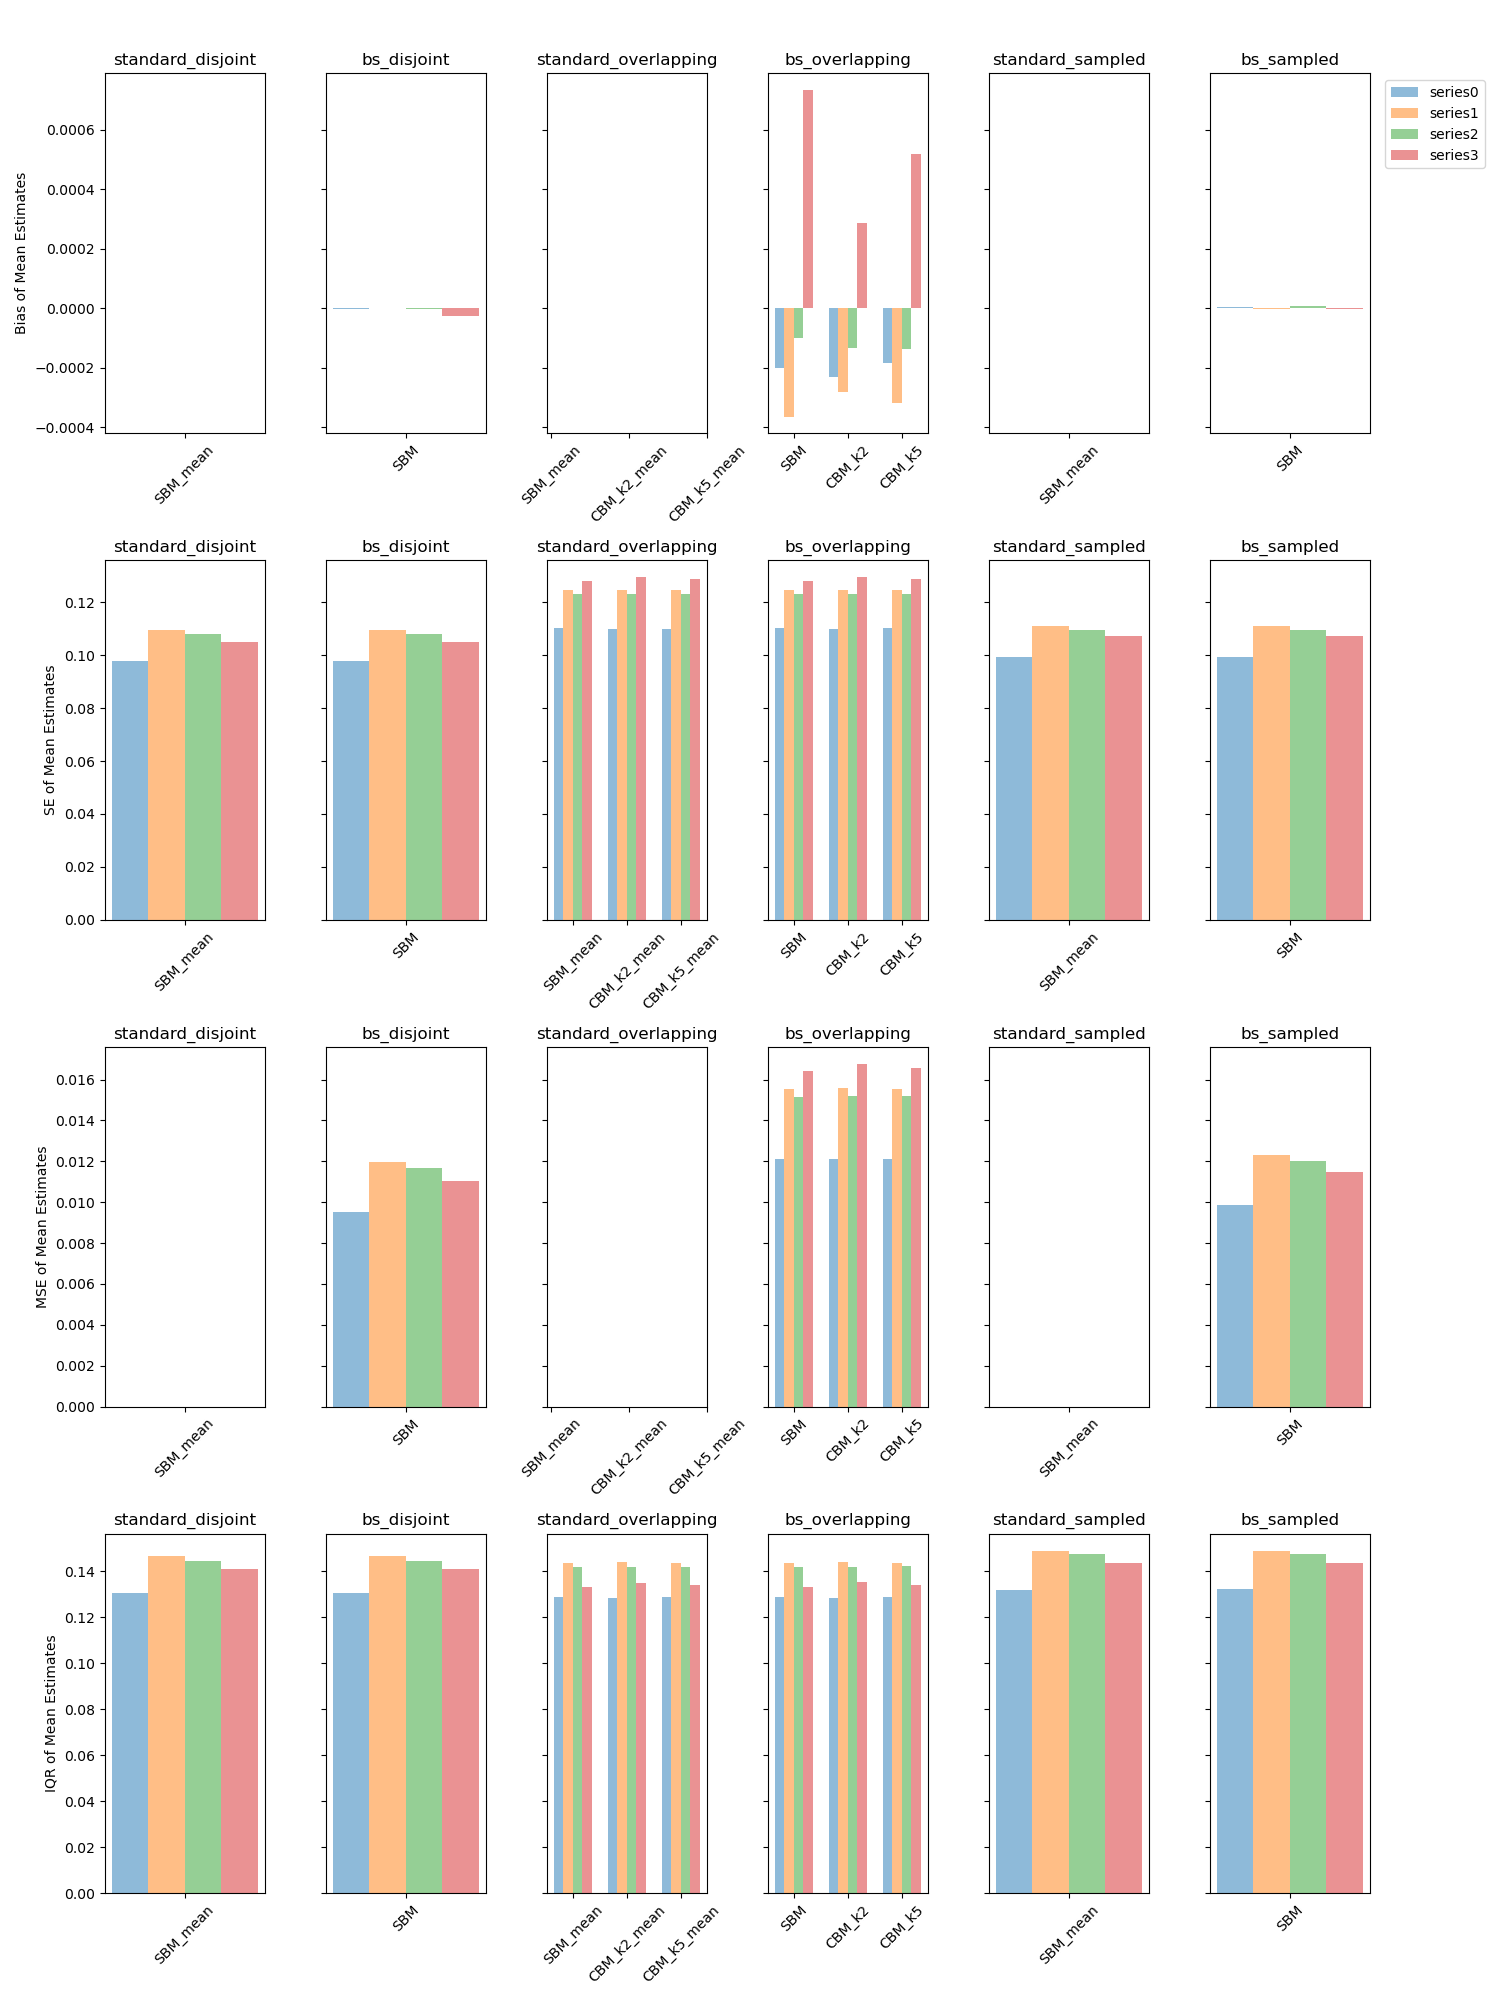

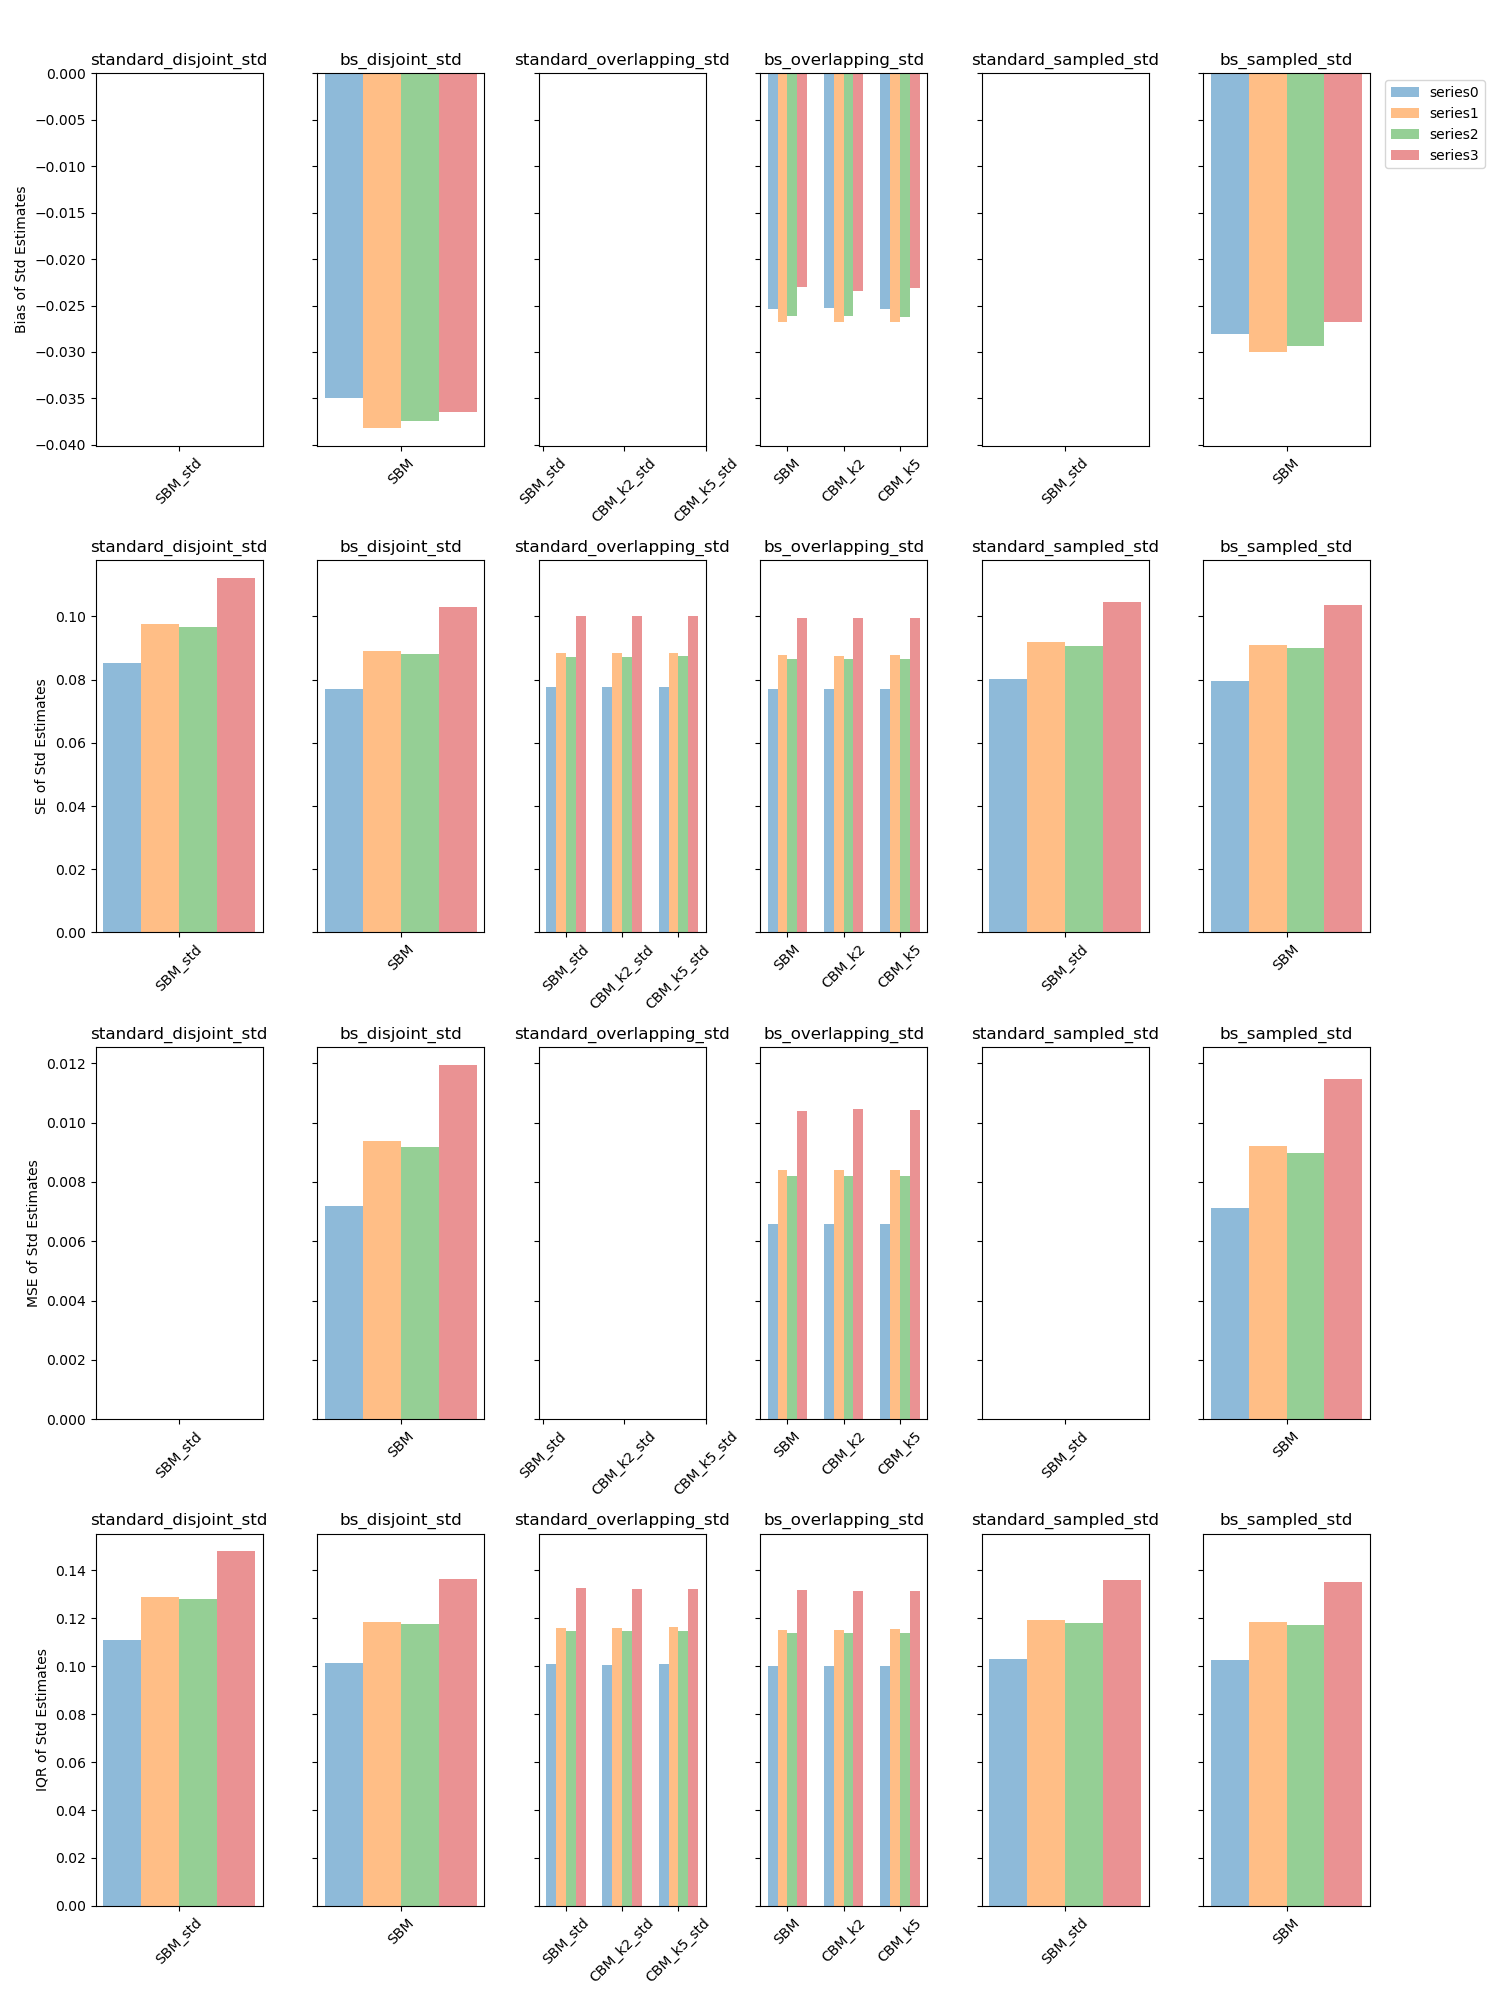

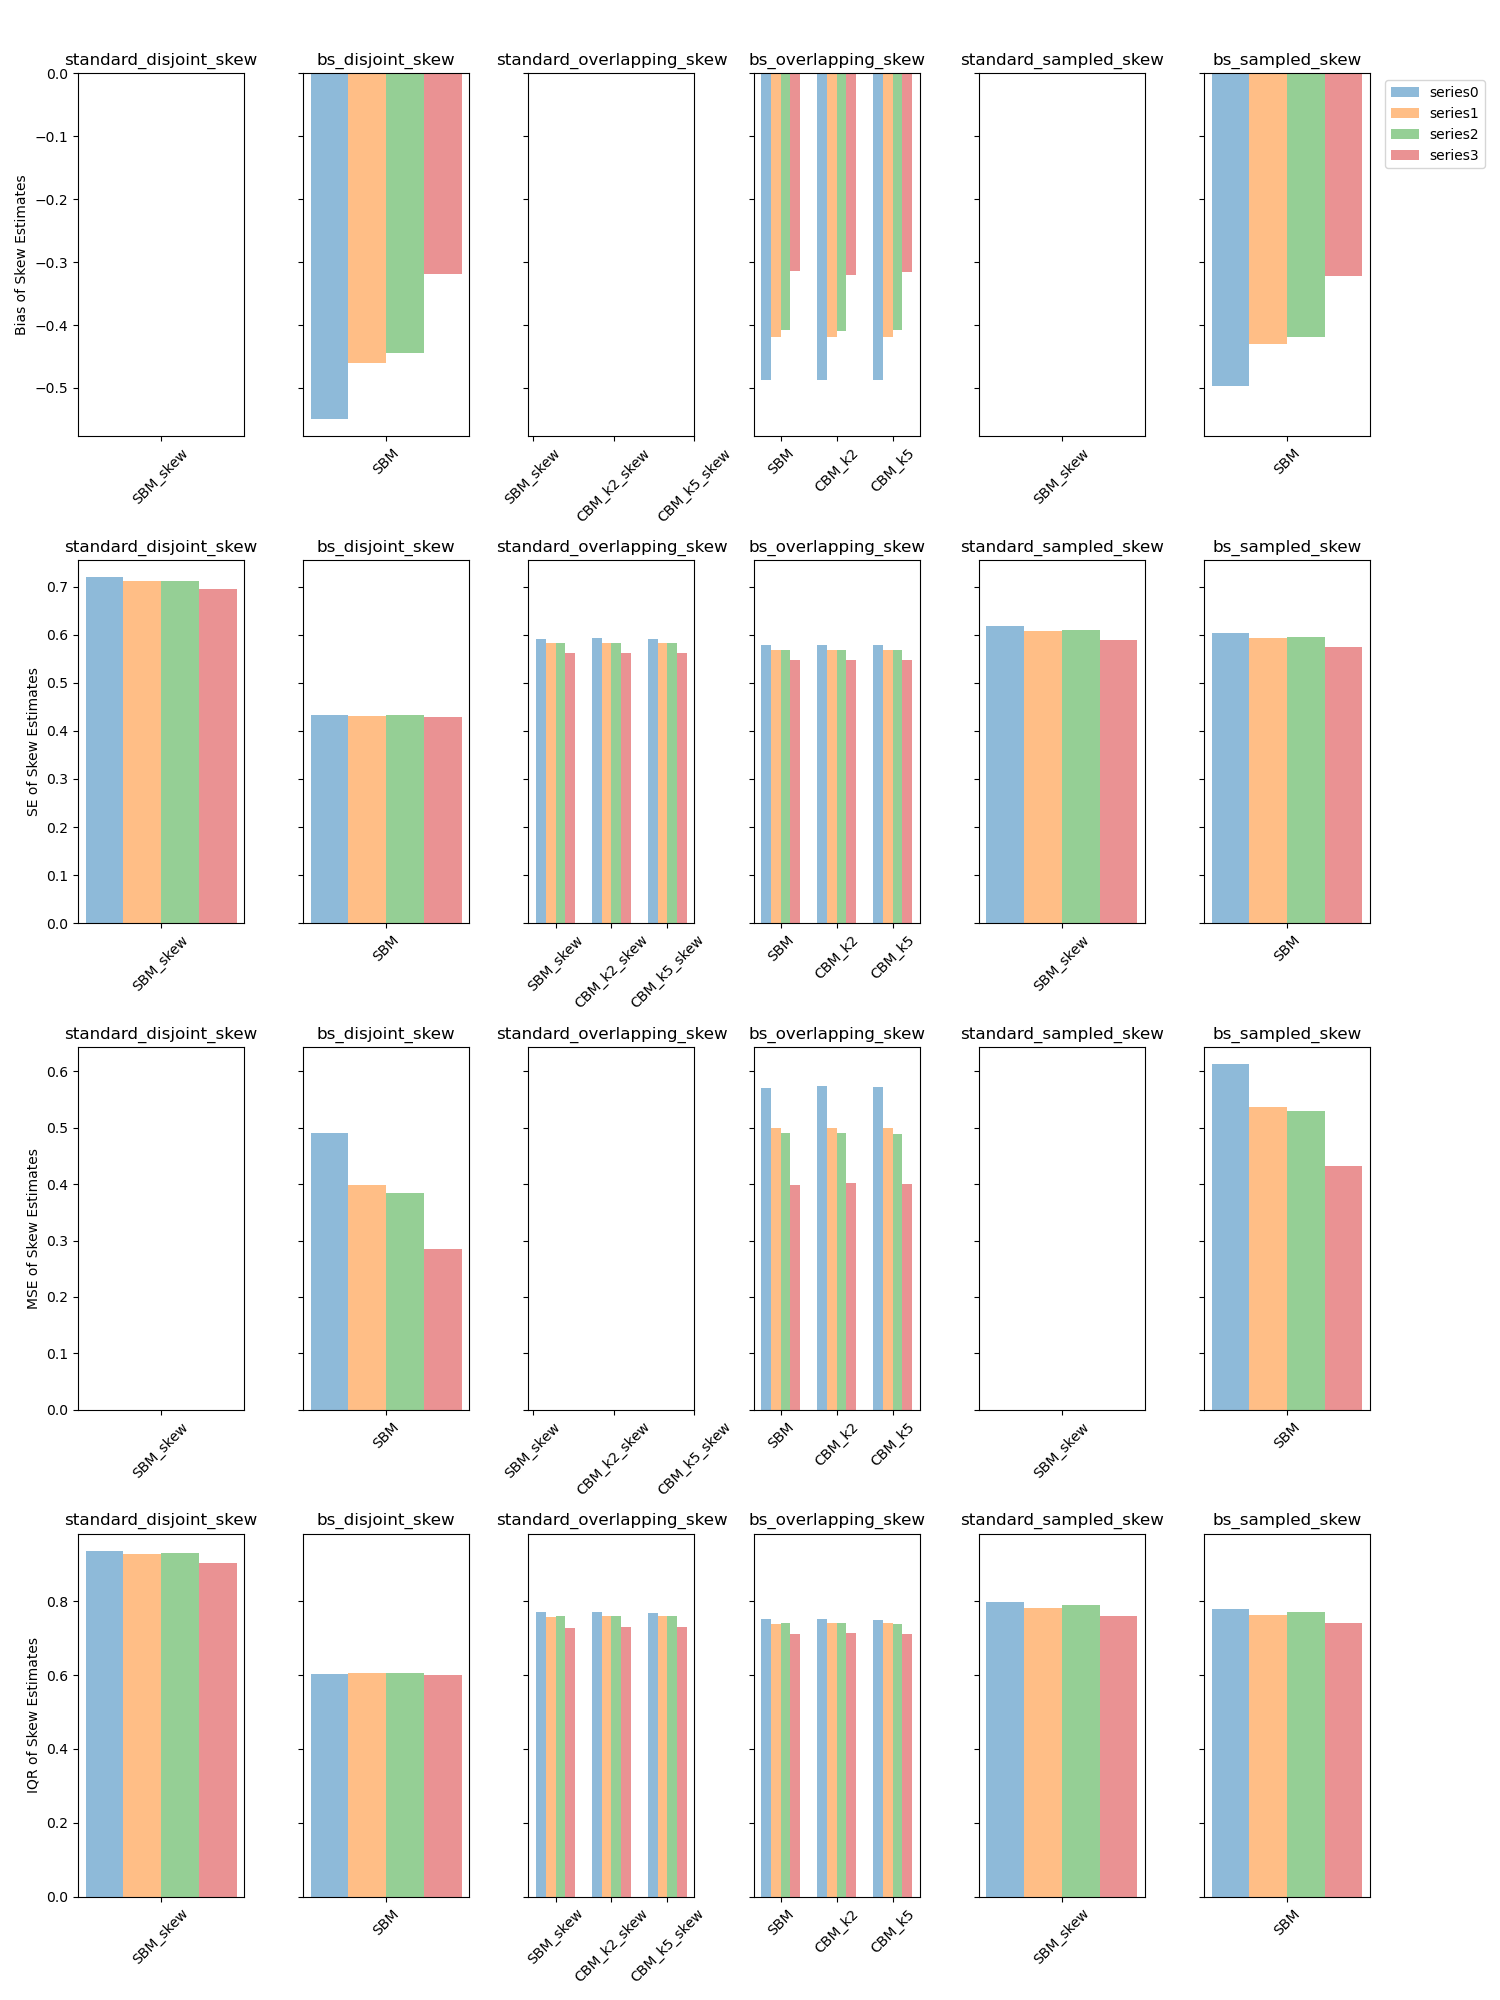

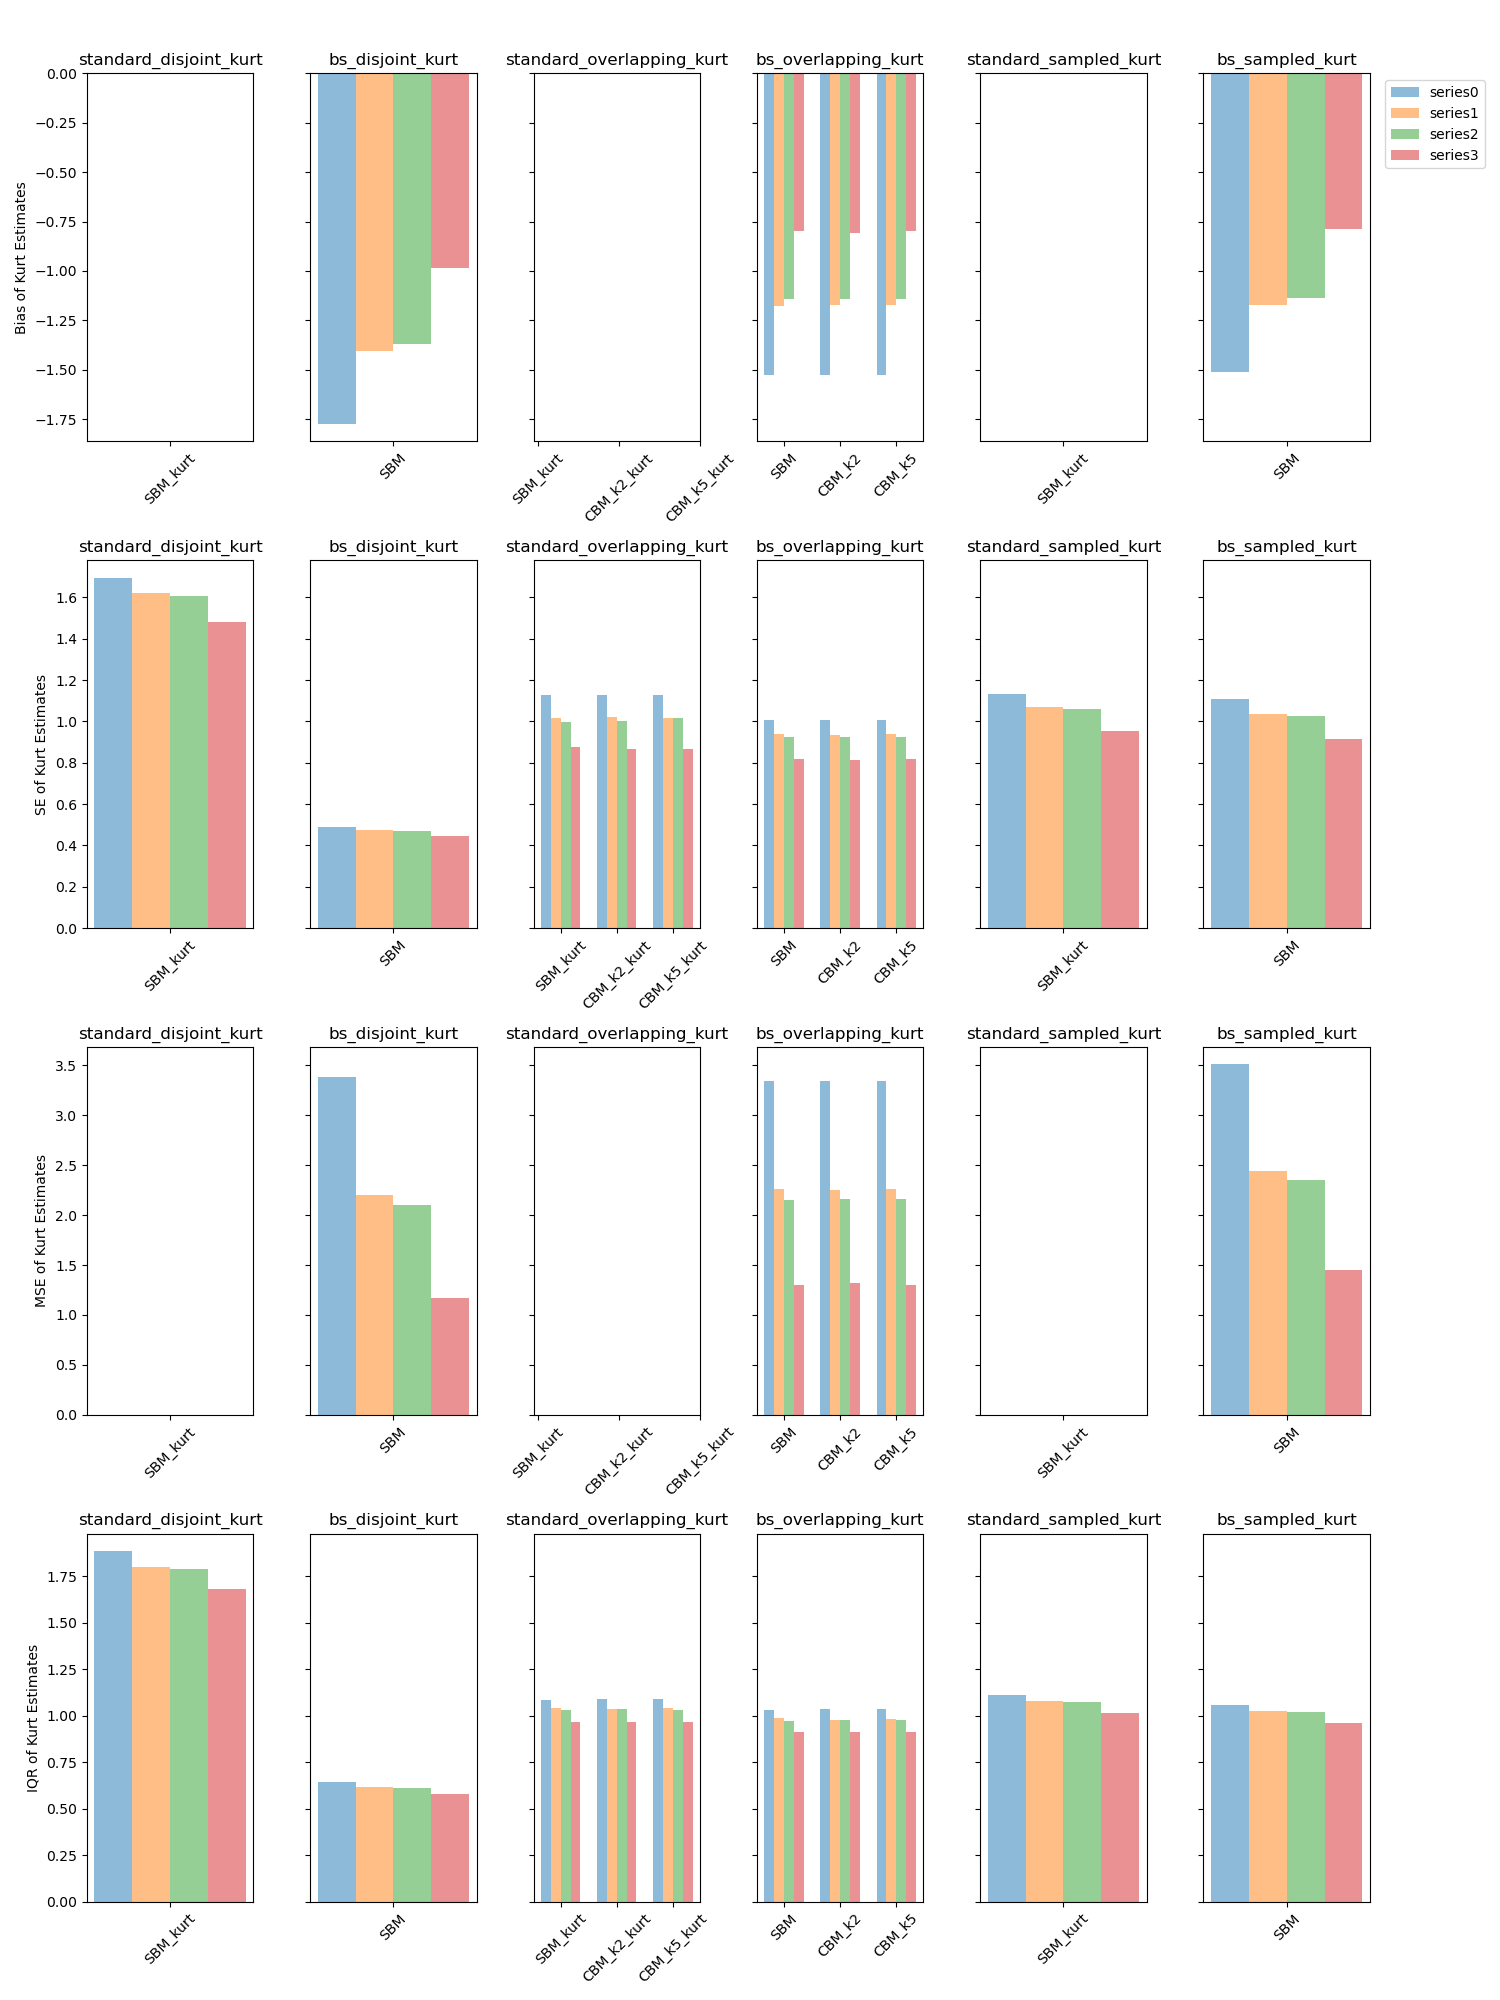

In [10]:
metric_labels = {
    'bias': 'Bias',
    'se': 'SE',
    'mse': 'MSE',
    'iqr': 'IQR',
}
plot_order = ['bias', 'se', 'mse', 'iqr']

for metric_name, metric_results in results_by_metric.items():
    if len(metric_results) == 0:
        continue

    estimator_types = list(metric_results.keys())

    available_metrics = []
    for plot_metric in plot_order:
        has_data = any(
            not metric_results[est_type][plot_metric].isna().all().all()
            for est_type in estimator_types
        )
        if has_data:
            available_metrics.append(plot_metric)

    if len(available_metrics) == 0:
        print(f"Skipping {metric_name}: no plottable metrics.")
        continue

    fig, axs = plt.subplots(
        len(available_metrics),
        len(estimator_types),
        figsize=(15, 5 * len(available_metrics)),
        layout='tight',
        sharey='row',
    )

    if len(available_metrics) == 1 and len(estimator_types) == 1:
        axs = np.array([[axs]])
    elif len(available_metrics) == 1:
        axs = axs.reshape(1, -1)
    elif len(estimator_types) == 1:
        axs = axs.reshape(-1, 1)

    for col_idx, est_type in enumerate(estimator_types):
        for row_idx, plot_metric in enumerate(available_metrics):
            ax = axs[row_idx, col_idx]

            df = metric_results[est_type][plot_metric].T
            x = np.arange(len(df.index))
            width = 0.7 / len(df.columns)

            for j, col in enumerate(df.columns):
                offset = width * j - (len(df.columns) - 1) * width / 2
                ax.bar(x + offset, df[col], width, alpha=0.5, label=f'{col}')

            ax.set_title(est_type.replace('_estimator', ''))
            ax.set_xticks(x)
            ax.set_xticklabels(df.index, rotation=45)

            if row_idx == 0 and col_idx == len(estimator_types) - 1:
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

            if col_idx == 0:
                ax.set_ylabel(f"{metric_labels[plot_metric]} of {metric_name[:-1].capitalize()} Estimates")

    fig.suptitle(f"{metric_name.capitalize()} Metrics", fontsize=16, y=1.02)
    plt.show()